# Monte Carlo BDPT Radiomap

This notebook runs the standalone Monte Carlo BDPT radiomap integrator on a three-cube scene.
BDPT uses per-cell LoS visibility, forward-constrained specular reflection, and a pure two-order wedge-diffraction profile for inspection: reflection-coupled diffraction families are disabled so the diffraction map contains `S -> D` and `S -> D -> D` only.

The forward view keeps the production reflection and diffraction sample budgets at 1,000,000 for component maps.
The gradient section uses a smaller common-random-number BDPT workload to estimate directional JVP maps by centered finite differences for `tx_x`, `cube1_x`, and `cube_1_material`.
The final AD availability cell checks that the current BDPT AD path executes and returns finite map data.
The diagnostic plots include the signed shadow-boundary correction field separately from the raw component powers.

In [1]:
from dataclasses import asdict
from pathlib import Path
import importlib
import sys

from IPython.display import display
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

repo_root = Path.cwd().resolve()
if not (repo_root / "witwin").exists():
    repo_root = next(path for path in repo_root.parents if (path / "witwin").exists())
repo_root_str = str(repo_root)
sys.path = [path for path in sys.path if str(Path(path or ".").resolve()) != repo_root_str]
sys.path.insert(0, repo_root_str)

importlib.invalidate_caches()
for module_name in tuple(sys.modules):
    if module_name == "witwin" or module_name.startswith("witwin."):
        sys.modules.pop(module_name, None)

from witwin.channel.core.scene import ReceiverGrid, Scene, Transmitter
from witwin.channel.core.scene.edge_policy import EdgePolicy
from witwin.core import Box, Material, Structure
from witwin.channel.montecarlo import Config, FilterConfig, IntegratorOptions, NativeExtension, Tuning, solve

display({
    "repo_root": repo_root_str,
    "native_extension_available": NativeExtension.native_extension_available(),
})

jitc_llvm_init(): LLVM API initialization failed ..


{'repo_root': 'E:\\Code\\witwin-platform\\channel',
 'native_extension_available': True}

## Scene and BDPT Configuration

In [2]:
BOUNDS = ((-10.0, 10.0), (-10.0, 10.0))
GRID_SHAPE = (256, 256)
SAMPLE_BUDGET = 1_000_000
GRADIENT_GRID_SHAPE = (256, 256)
GRADIENT_SAMPLE_BUDGET = 65_536
GRADIENT_MAX_DIFFRACTIONS = 1
GRADIENT_FD_STEP = 1.0e-3
GRADIENT_MATERIAL_FD_STEP = 1.0e-2
PLANE_Z = 1.0
FREQUENCY_HZ = 1.0e9
TX_POS = (0.0, -5.0, 4.0)
CUBE_CENTERS = (
    (-2.5, -3.0, 1.5),
    (2.0, 0.5, 1.5),
    (-0.5, 3.5, 1.5),
)
CUBE_SIZE = (2.0, 2.0, 2.0)
DEFAULT_MATERIAL_EPS_R = 4.0
DEFAULT_MATERIAL_SIGMA_E = 0.0
MONTE_CARLO_FILTERING = FilterConfig(
    reflection={"method": "gaussian", "radius": 1, "sigma": 0.9, "blend": 0.75},
    diffraction={"method": "bilateral", "radius": 2, "sigma": 1.25, "range_sigma": 2.0e-5, "blend": 1.0},
)


def make_scene(*, cube1_x=None, cube_1_material=None, tx_pos=TX_POS):
    structures = []
    for index, center in enumerate(CUBE_CENTERS):
        resolved_center = center
        if index == 0 and cube1_x is not None:
            resolved_center = (float(cube1_x), center[1], center[2])
        resolved_eps_r = DEFAULT_MATERIAL_EPS_R
        if index == 0 and cube_1_material is not None:
            resolved_eps_r = float(cube_1_material)
        structures.append(
            Structure(
                name=f"cube_{index}",
                geometry=Box(position=resolved_center, size=CUBE_SIZE, device="cuda"),
                material=Material(eps_r=resolved_eps_r, sigma_e=DEFAULT_MATERIAL_SIGMA_E),
            )
        )
    return Scene(structures=structures, transmitters=[Transmitter("tx", tx_pos)], frequency=FREQUENCY_HZ, device="cuda")


def make_bdpt_config(*, sample_budget, max_diffraction_order, ad=False):
    return Config(
        num_samples=int(sample_budget),
        max_bounces=1,
        max_diffraction_order=int(max_diffraction_order),
        edge_policy=EdgePolicy(edge_selection_mode="all_edges"),
        tuning=Tuning(
            enable_rd_diffraction=True,
            enable_bdpt_reflection_coupled_diffraction=False,
            shadow_boundary_mode="none" if bool(ad) else "utd_power_smoothing",
        ),
        integrator_options=IntegratorOptions(
            integrator="bdpt",
            samples_per_tx=int(sample_budget),
            accumulation_backend="auto",
            seed=7,
            ad=bool(ad),
        ),
        filtering=MONTE_CARLO_FILTERING,
    )


scene = make_scene()
grid = ReceiverGrid("rm", axis="z", position=PLANE_Z, bounds=BOUNDS, grid_shape=GRID_SHAPE)
gradient_grid = ReceiverGrid("rm_gradient", axis="z", position=PLANE_Z, bounds=BOUNDS, grid_shape=GRADIENT_GRID_SHAPE)
scene.add(grid)
config = make_bdpt_config(sample_budget=SAMPLE_BUDGET, max_diffraction_order=2, ad=False)
gradient_config = make_bdpt_config(
    sample_budget=GRADIENT_SAMPLE_BUDGET,
    max_diffraction_order=GRADIENT_MAX_DIFFRACTIONS,
    ad=False,
)
gradient_ad_config = make_bdpt_config(
    sample_budget=GRADIENT_SAMPLE_BUDGET,
    max_diffraction_order=GRADIENT_MAX_DIFFRACTIONS,
    ad=True,
)

display({
    "grid_shape": GRID_SHAPE,
    "sample_budget": SAMPLE_BUDGET,
    "samples_per_tx": config.integrator_options.samples_per_tx,
    "num_samples": config.num_samples,
    "max_bounces": config.max_bounces,
    "max_diffraction_order": config.max_diffraction_order,
    "reflection_coupled_diffraction": config.tuning.enable_bdpt_reflection_coupled_diffraction,
    "filtering": asdict(config.filtering) if config.filtering is not None else None,
    "default_material_eps_r": DEFAULT_MATERIAL_EPS_R,
    "gradient_grid_shape": GRADIENT_GRID_SHAPE,
    "gradient_sample_budget": GRADIENT_SAMPLE_BUDGET,
    "gradient_max_diffraction_order": GRADIENT_MAX_DIFFRACTIONS,
})

{'grid_shape': (256, 256),
 'sample_budget': 1000000,
 'samples_per_tx': 1000000,
 'num_samples': 1000000,
 'max_bounces': 1,
 'max_diffraction_order': 2,
 'reflection_coupled_diffraction': False,
 'filtering': {'reflection': {'method': 'gaussian',
   'radius': 1,
   'sigma': 0.9,
   'range_sigma': None,
   'blend': 0.75},
  'diffraction': {'method': 'bilateral',
   'radius': 2,
   'sigma': 1.25,
   'range_sigma': 2e-05,
   'blend': 1.0}},
 'default_material_eps_r': 4.0,
 'gradient_grid_shape': (256, 256),
 'gradient_sample_budget': 65536,
 'gradient_max_diffraction_order': 1}

## Run BDPT

In [3]:
if not NativeExtension.native_extension_available():
    raise RuntimeError("The Monte Carlo native extension is required for this BDPT example.")

result = solve(
    scene=scene,
    transmitter="tx",
    receiver="rm",
    config=config,
)
path_gain = np.asarray(result.path_gain, dtype=np.float32)
raw_total = np.asarray(result.incoherent["raw_total"], dtype=np.float32)
shadow_boundary_correction = np.asarray(result.incoherent["shadow_boundary_correction"], dtype=np.float32)
incident_shadow_boundary_weight = np.asarray(result.incoherent["incident_shadow_boundary_weight"], dtype=np.float32)
reflection_shadow_boundary_weight = np.asarray(result.incoherent["reflection_shadow_boundary_weight"], dtype=np.float32)
components = {
    name: np.asarray(result.incoherent[name], dtype=np.float32)
    for name in ("los", "reflection", "diffraction", "total")
}
shadow_boundary_summary = {
    "sum": float(np.sum(shadow_boundary_correction, dtype=np.float64)),
    "abs_sum": float(np.sum(np.abs(shadow_boundary_correction), dtype=np.float64)),
    "min": float(np.min(shadow_boundary_correction)),
    "max": float(np.max(shadow_boundary_correction)),
    "nonzero_cells": int(np.count_nonzero(shadow_boundary_correction != 0.0)),
}
component_summary = {}
for name, values in components.items():
    values = np.asarray(values, dtype=np.float32)
    db_values = 10.0 * np.log10(np.maximum(values, 1.0e-16))
    component_summary[name] = {
        "sum": float(np.sum(values, dtype=np.float64)),
        "max": float(np.max(values)),
        "nonzero_cells": int(np.count_nonzero(values > 0.0)),
        "cells_above_-90_db": int(np.count_nonzero(db_values > -90.0)),
        "cells_above_-120_db": int(np.count_nonzero(db_values > -120.0)),
    }

display({
    "path_gain_shape": path_gain.shape,
    "path_gain_min": float(np.nanmin(path_gain)),
    "path_gain_max": float(np.nanmax(path_gain)),
    "component_summary": component_summary,
    "shadow_boundary_summary": shadow_boundary_summary,
    "integrator": result.metadata["integrator"],
    "bdpt_version": result.metadata["bdpt"]["version"],
    "mis_policy": result.metadata["bdpt"]["mis_policy"],
    "diffraction_strategies": result.metadata["bdpt"]["strategies"],
})

{'path_gain_shape': (1, 256, 256),
 'path_gain_min': 0.0,
 'path_gain_max': 0.1334669291973114,
 'component_summary': {'los': {'sum': 0.6220265990289136,
   'max': 6.321671389741823e-05,
   'nonzero_cells': 52670,
   'cells_above_-90_db': 52670,
   'cells_above_-120_db': 52670},
  'reflection': {'sum': 0.009741797679971853,
   'max': 1.9155153495376e-05,
   'nonzero_cells': 7075,
   'cells_above_-90_db': 7075,
   'cells_above_-120_db': 7075},
  'diffraction': {'sum': 0.2591320508097435,
   'max': 0.13342119753360748,
   'nonzero_cells': 59430,
   'cells_above_-90_db': 7346,
   'cells_above_-120_db': 37607},
  'total': {'sum': 0.8826096614986457,
   'max': 0.1334669291973114,
   'nonzero_cells': 65455,
   'cells_above_-90_db': 61862,
   'cells_above_-120_db': 64063}},
 'shadow_boundary_summary': {'sum': -0.008290796116641547,
  'abs_sum': 0.012253168241975969,
  'min': -1.4017631656315643e-05,
  'max': 4.328881459514378e-06,
  'nonzero_cells': 52246},
 'integrator': 'bdpt',
 'bdpt_versi

## Visualize Path Gain

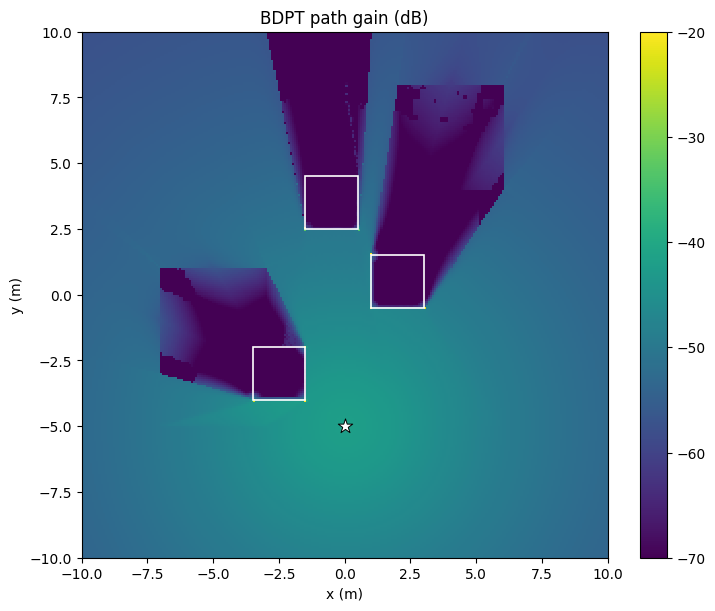

In [4]:
RADIO_MAP_DB_MIN = -70.0
RADIO_MAP_DB_MAX = -20.0


def map2d(values):
    array = np.asarray(values)
    if array.ndim == 3 and array.shape[0] == 1:
        return array[0]
    return array


def power_db(values, *, floor_db=-160.0):
    floor = 10.0 ** (floor_db / 10.0)
    return 10.0 * np.log10(np.maximum(map2d(values).astype(np.float32, copy=False), floor))


def signed_power_db(values, *, floor_db=-160.0):
    values = map2d(values).astype(np.float32, copy=False)
    floor = 10.0 ** (floor_db / 10.0)
    magnitude_db = 10.0 * np.log10(np.maximum(np.abs(values), floor))
    encoded = np.sign(values) * np.maximum(magnitude_db - floor_db, 0.0)
    encoded[values == 0.0] = 0.0
    return encoded


def signed_db_limit(values, *, floor_db=-160.0):
    encoded = np.abs(signed_power_db(values, floor_db=floor_db)).reshape(-1)
    return max(float(np.nanpercentile(encoded, 99.0)), 1.0)


def component_db_limits(values, *, floor_db=-160.0, lower_q=0.02, upper_q=0.995, min_span_db=35.0):
    values = map2d(values).astype(np.float32, copy=False)
    active_db = power_db(values[values > 0.0], floor_db=floor_db)
    if active_db.size == 0:
        return floor_db, -20.0
    vmin = max(floor_db, float(np.floor(np.quantile(active_db, lower_q) / 5.0) * 5.0))
    vmax = min(-20.0, float(np.ceil(np.quantile(active_db, upper_q) / 5.0) * 5.0))
    if vmax - vmin < min_span_db:
        vmin = max(floor_db, vmax - min_span_db)
    return vmin, vmax


def add_scene_overlay(ax):
    ax.scatter([TX_POS[0]], [TX_POS[1]], marker="*", s=120, c="white", edgecolors="black", linewidths=0.7)
    for center in CUBE_CENTERS:
        lower_left = (center[0] - CUBE_SIZE[0] / 2.0, center[1] - CUBE_SIZE[1] / 2.0)
        rect = Rectangle(
            lower_left,
            CUBE_SIZE[0],
            CUBE_SIZE[1],
            fill=False,
            edgecolor="white",
            linewidth=1.2,
        )
        ax.add_patch(rect)


fig, ax = plt.subplots(figsize=(7.0, 6.0), constrained_layout=True)
image = ax.imshow(
    power_db(path_gain),
    origin="lower",
    extent=(BOUNDS[0][0], BOUNDS[0][1], BOUNDS[1][0], BOUNDS[1][1]),
    cmap="viridis",
    interpolation="nearest",
    vmin=RADIO_MAP_DB_MIN,
    vmax=RADIO_MAP_DB_MAX,
)
add_scene_overlay(ax)
ax.set_title("BDPT path gain (dB)")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
plt.show()

## Component Contributions

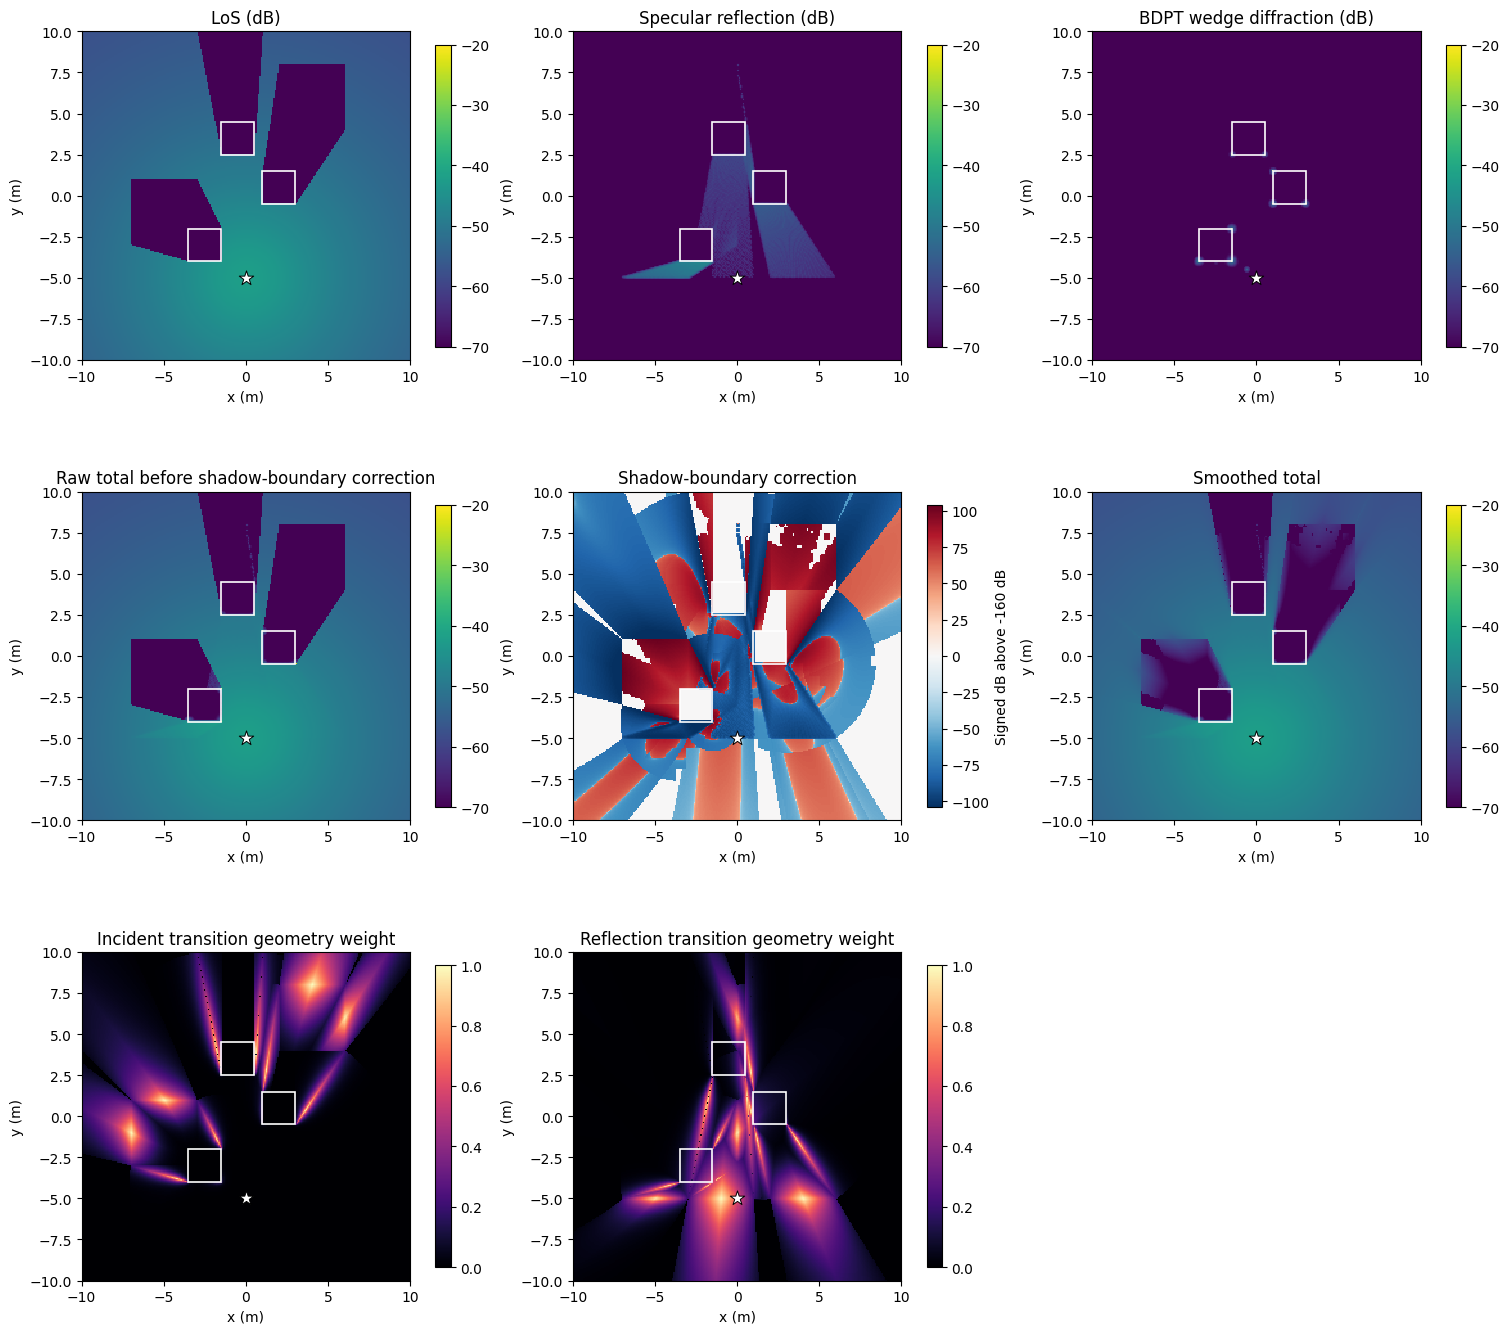

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15.0, 13.8), constrained_layout=True)
for ax, name, title in zip(
    axes[0],
    ("los", "reflection", "diffraction"),
    ("LoS", "Specular reflection", "BDPT wedge diffraction"),
):
    image = ax.imshow(
        power_db(components[name]),
        origin="lower",
        extent=(BOUNDS[0][0], BOUNDS[0][1], BOUNDS[1][0], BOUNDS[1][1]),
        cmap="viridis",
        interpolation="nearest",
        vmin=RADIO_MAP_DB_MIN,
        vmax=RADIO_MAP_DB_MAX,
    )
    add_scene_overlay(ax)
    ax.set_title(f"{title} (dB)")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.03)

shadow_panels = (
    (raw_total, "Raw total before shadow-boundary correction", "power"),
    (shadow_boundary_correction, "Shadow-boundary correction", "signed"),
    (components["total"], "Smoothed total", "power"),
)
for ax, values, title, scale in zip(axes[1], *zip(*shadow_panels)):
    if scale == "signed":
        display_values = signed_power_db(values)
        limit = signed_db_limit(values)
        image = ax.imshow(
            display_values,
            origin="lower",
            extent=(BOUNDS[0][0], BOUNDS[0][1], BOUNDS[1][0], BOUNDS[1][1]),
            cmap="RdBu_r",
            interpolation="nearest",
            vmin=-limit,
            vmax=limit,
        )
        colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
        colorbar.set_label("Signed dB above -160 dB")
    else:
        image = ax.imshow(
            power_db(values),
            origin="lower",
            extent=(BOUNDS[0][0], BOUNDS[0][1], BOUNDS[1][0], BOUNDS[1][1]),
            cmap="viridis",
            interpolation="nearest",
            vmin=RADIO_MAP_DB_MIN,
            vmax=RADIO_MAP_DB_MAX,
        )
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
    add_scene_overlay(ax)
    ax.set_title(title)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")

weight_panels = (
    (incident_shadow_boundary_weight, "Incident transition geometry weight"),
    (reflection_shadow_boundary_weight, "Reflection transition geometry weight"),
)
for ax, values, title in zip(axes[2, :2], *zip(*weight_panels)):
    image = ax.imshow(
        map2d(values),
        origin="lower",
        extent=(BOUNDS[0][0], BOUNDS[0][1], BOUNDS[1][0], BOUNDS[1][1]),
        cmap="magma",
        interpolation="nearest",
        vmin=0.0,
        vmax=1.0,
    )
    add_scene_overlay(ax)
    ax.set_title(title)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
axes[2, 2].axis("off")
plt.show()

## BDPT Gradient Estimates

These cells use a smaller common-random-number BDPT workload and centered differences to estimate directional JVP maps for the requested parameters. The estimate is not a true BDPT AD JVP; it is the bounded primal estimator used until BDPT exposes a real AD backend.

In [6]:
GRADIENT_PARAMETERS = ("tx_x", "cube1_x", "cube_1_material")
GRADIENT_COMPONENTS = ("los", "reflection", "diffraction")
GRADIENT_DB_FLOOR = -160.0
GRADIENT_STEPS = {
    "tx_x": GRADIENT_FD_STEP,
    "cube1_x": GRADIENT_FD_STEP,
    "cube_1_material": GRADIENT_MATERIAL_FD_STEP,
}
GRADIENT_LABELS = {
    "tx_x": "tx_x",
    "cube1_x": "cube1_x",
    "cube_1_material": "cube 1 material eps_r",
}


def solve_bdpt_variant(*, tx_x=None, cube1_x=None, cube_1_material=None, config_override=None, grid_override=None):
    resolved_tx_x = TX_POS[0] if tx_x is None else float(tx_x)
    selected_grid = gradient_grid if grid_override is None else grid_override
    variant_scene = make_scene(
        cube1_x=cube1_x,
        cube_1_material=cube_1_material,
        tx_pos=(resolved_tx_x, TX_POS[1], TX_POS[2]),
    )
    variant_scene.add(selected_grid)
    return solve(
        scene=variant_scene,
        transmitter="tx",
        receiver=selected_grid.name,
        config=gradient_config if config_override is None else config_override,
    )


def snapshot_arrays(result):
    return {
        "path_gain": np.asarray(result.path_gain, dtype=np.float64),
        "components": {
            name: np.asarray(result.incoherent[name], dtype=np.float64)
            for name in GRADIENT_COMPONENTS
        },
        "metadata": dict(result.metadata),
    }


def solve_parameter_offset(parameter, offset):
    if parameter == "tx_x":
        return snapshot_arrays(solve_bdpt_variant(tx_x=TX_POS[0] + float(offset)))
    if parameter == "cube1_x":
        return snapshot_arrays(solve_bdpt_variant(cube1_x=CUBE_CENTERS[0][0] + float(offset)))
    if parameter == "cube_1_material":
        return snapshot_arrays(
            solve_bdpt_variant(cube_1_material=DEFAULT_MATERIAL_EPS_R + float(offset))
        )
    raise ValueError(f"Unsupported gradient parameter: {parameter!r}")


def estimate_bdpt_jvp(parameter):
    step = float(GRADIENT_STEPS[parameter])
    plus = solve_parameter_offset(parameter, step)
    minus = solve_parameter_offset(parameter, -step)
    scale = 1.0 / (2.0 * step)
    return {
        "parameter": parameter,
        "step": step,
        "jvp": (plus["path_gain"] - minus["path_gain"]) * scale,
        "component_jvp": {
            name: (plus["components"][name] - minus["components"][name]) * scale
            for name in GRADIENT_COMPONENTS
        },
        "plus_metadata": plus["metadata"],
        "minus_metadata": minus["metadata"],
    }


def signed_gradient_db(values, *, floor_db=GRADIENT_DB_FLOOR):
    values = map2d(values).astype(np.float64, copy=False)
    floor_linear = 10.0 ** (float(floor_db) / 10.0)
    magnitude_db = 10.0 * np.log10(np.maximum(np.abs(values), floor_linear))
    encoded = np.sign(values) * np.maximum(magnitude_db - float(floor_db), 0.0)
    return np.where(values == 0.0, 0.0, encoded)


def gradient_display_limit(*value_groups, floor_db=GRADIENT_DB_FLOOR):
    encoded = [
        np.abs(signed_gradient_db(values, floor_db=floor_db)).reshape(-1)
        for values in value_groups
    ]
    finite = np.concatenate(encoded) if encoded else np.array([1.0])
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return 1.0
    return max(1.0, float(np.nanpercentile(finite, 99.0)))


def show_gradient_panel(ax, values, title, *, limit):
    image = ax.imshow(
        signed_gradient_db(values),
        origin="lower",
        extent=(BOUNDS[0][0], BOUNDS[0][1], BOUNDS[1][0], BOUNDS[1][1]),
        cmap="RdBu_r",
        interpolation="nearest",
        vmin=-limit,
        vmax=limit,
    )
    add_scene_overlay(ax)
    ax.set_title(title)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    return image

In [7]:
if not NativeExtension.native_extension_available():
    raise RuntimeError("The Monte Carlo native extension is required for BDPT gradient estimates.")

bdpt_gradient_estimates = {
    parameter: estimate_bdpt_jvp(parameter)
    for parameter in GRADIENT_PARAMETERS
}
display({
    parameter: {
        "step": estimate["step"],
        "path_gain_abs_sum": float(np.sum(np.abs(estimate["jvp"]), dtype=np.float64)),
        "path_gain_abs_max": float(np.max(np.abs(estimate["jvp"]))),
        "diffraction_abs_sum": float(
            np.sum(np.abs(estimate["component_jvp"]["diffraction"]), dtype=np.float64)
        ),
    }
    for parameter, estimate in bdpt_gradient_estimates.items()
})

{'tx_x': {'step': 0.001,
  'path_gain_abs_sum': 0.3216882993127885,
  'path_gain_abs_max': 0.03897026181221008,
  'diffraction_abs_sum': 0.05593635989682805},
 'cube1_x': {'step': 0.001,
  'path_gain_abs_sum': 0.08818190490891831,
  'path_gain_abs_max': 0.038918107748031616,
  'diffraction_abs_sum': 0.0636050764810421},
 'cube_1_material': {'step': 0.01,
  'path_gain_abs_sum': 0.0005181854157348953,
  'path_gain_abs_max': 1.8439095583744347e-06,
  'diffraction_abs_sum': 1.869725593534738e-07}}

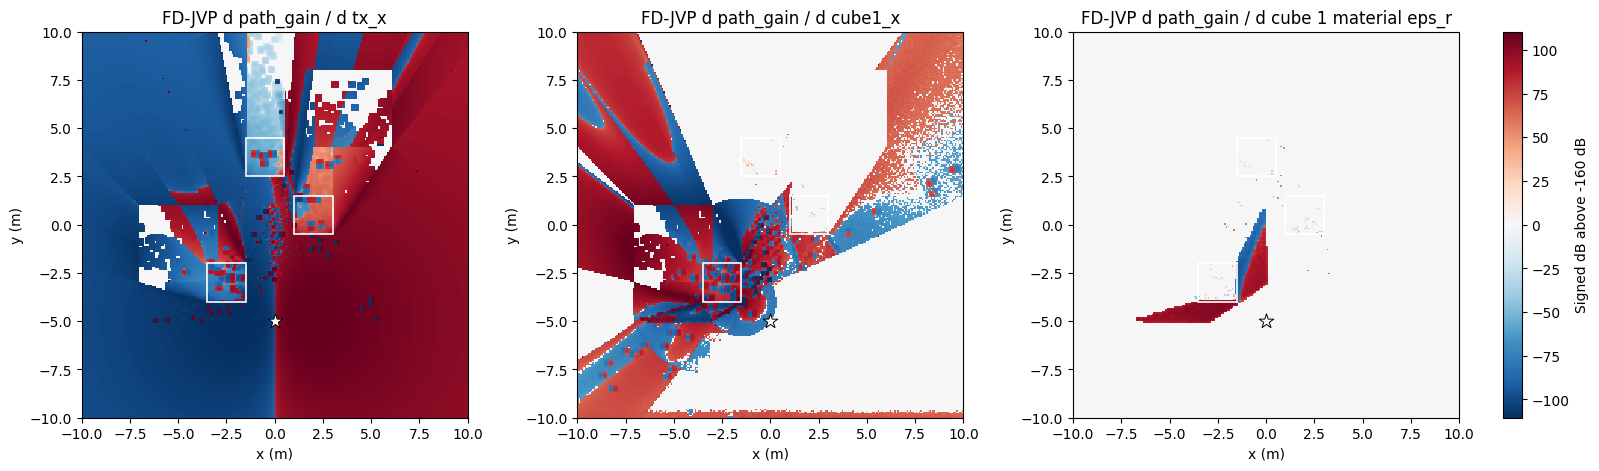

In [8]:
fig, axes = plt.subplots(1, len(GRADIENT_PARAMETERS), figsize=(16.0, 4.6), constrained_layout=True)
limit = gradient_display_limit(*(bdpt_gradient_estimates[p]["jvp"] for p in GRADIENT_PARAMETERS))
for ax, parameter in zip(axes, GRADIENT_PARAMETERS):
    image = show_gradient_panel(
        ax,
        bdpt_gradient_estimates[parameter]["jvp"],
        f"FD-JVP d path_gain / d {GRADIENT_LABELS[parameter]}",
        limit=limit,
    )
colorbar = fig.colorbar(image, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
colorbar.set_label(f"Signed dB above {GRADIENT_DB_FLOOR:.0f} dB")
plt.show()

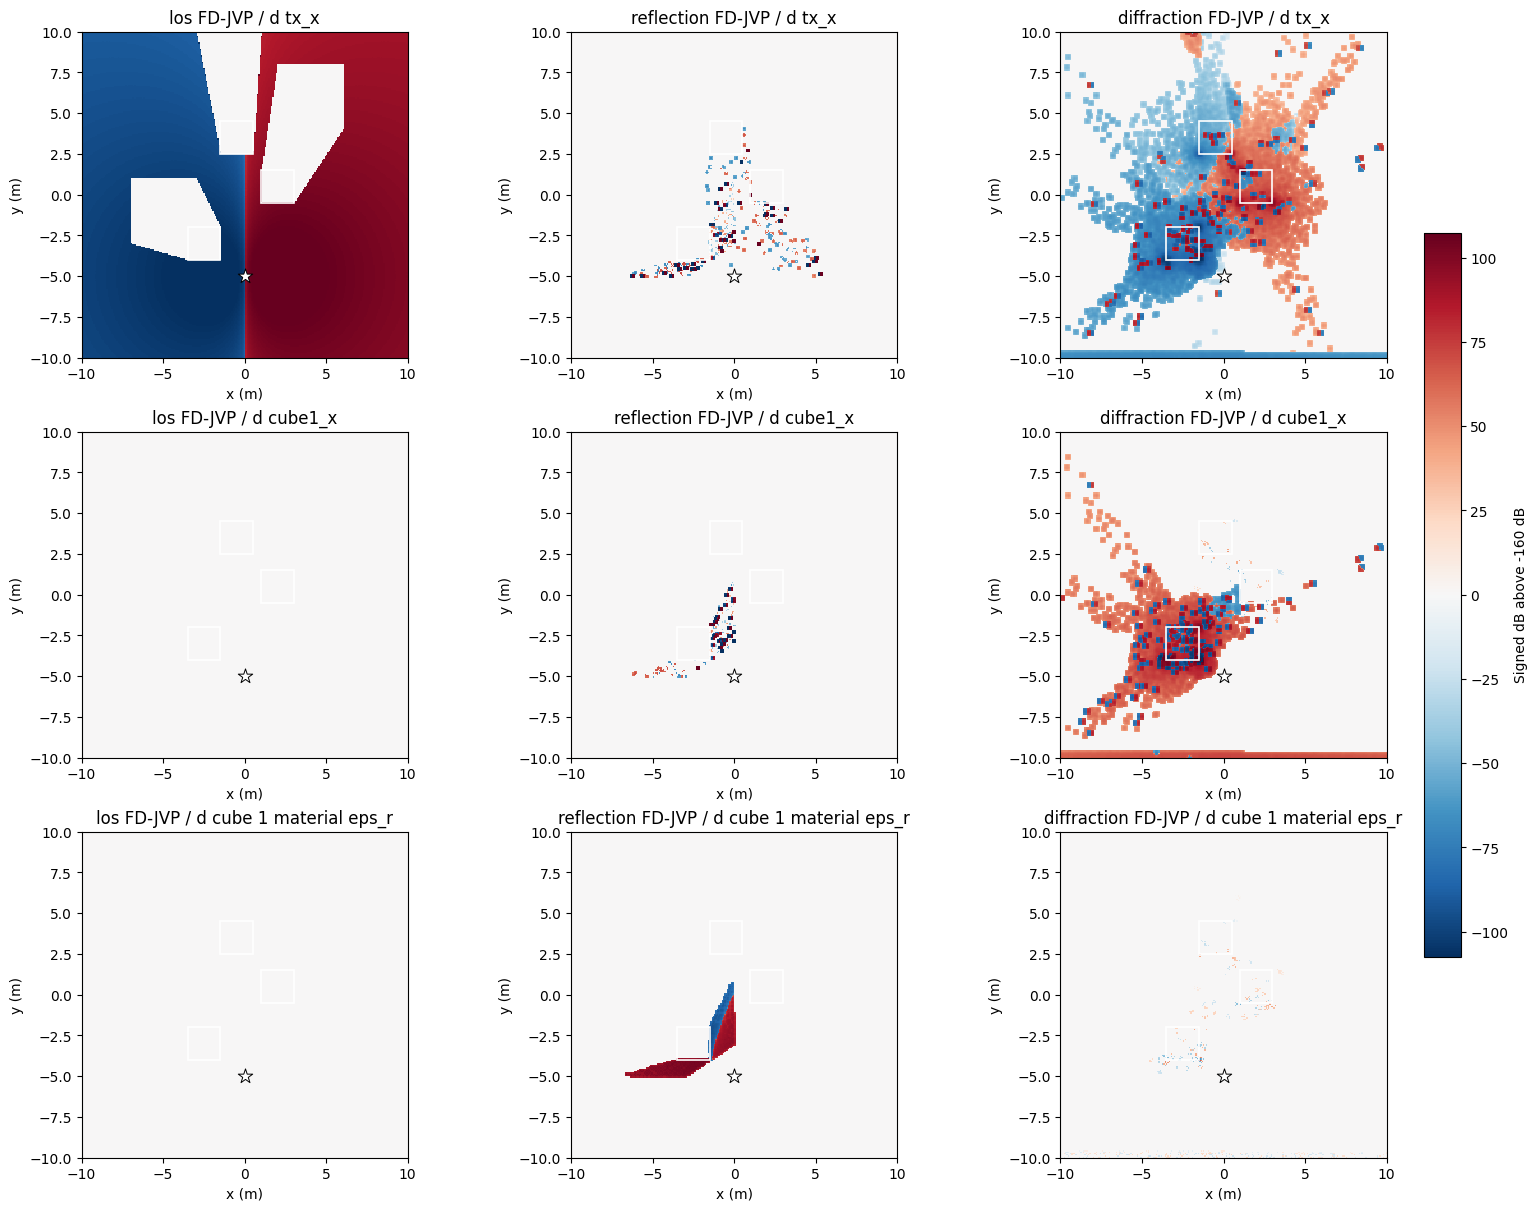

In [9]:
fig, axes = plt.subplots(
    len(GRADIENT_PARAMETERS),
    len(GRADIENT_COMPONENTS),
    figsize=(16.0, 12.0),
    constrained_layout=True,
)
limit = gradient_display_limit(
    *(
        bdpt_gradient_estimates[parameter]["component_jvp"][component]
        for parameter in GRADIENT_PARAMETERS
        for component in GRADIENT_COMPONENTS
    )
)
for row, parameter in enumerate(GRADIENT_PARAMETERS):
    for col, component in enumerate(GRADIENT_COMPONENTS):
        image = show_gradient_panel(
            axes[row, col],
            bdpt_gradient_estimates[parameter]["component_jvp"][component],
            f"{component} FD-JVP / d {GRADIENT_LABELS[parameter]}",
            limit=limit,
        )
colorbar = fig.colorbar(image, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
colorbar.set_label(f"Signed dB above {GRADIENT_DB_FLOOR:.0f} dB")
plt.show()

## BDPT AD Availability Check

This cell verifies that the current `IntegratorOptions(ad=True)` BDPT path executes on the gradient workload and returns finite map data.

In [10]:
def bdpt_ad_availability_check(parameter):
    result = solve_bdpt_variant(config_override=gradient_ad_config)
    snapshot = snapshot_arrays(result)
    path_gain = snapshot["path_gain"]
    return {
        "parameter": parameter,
        "status": "bdpt_ad_available",
        "path_gain_sum": float(np.sum(path_gain, dtype=np.float64)),
        "all_finite": bool(np.all(np.isfinite(path_gain))),
        "ad_mode": snapshot["metadata"].get("monte_carlo", {}).get("ad_mode"),
    }


bdpt_ad_checks = {
    parameter: bdpt_ad_availability_check(parameter)
    for parameter in GRADIENT_PARAMETERS
}
display(bdpt_ad_checks)
assert all(check["status"] == "bdpt_ad_available" for check in bdpt_ad_checks.values())
assert all(check["all_finite"] for check in bdpt_ad_checks.values())

{'tx_x': {'parameter': 'tx_x',
  'status': 'bdpt_ad_available',
  'path_gain_sum': 0.7945661929158842,
  'all_finite': True,
  'ad_mode': True},
 'cube1_x': {'parameter': 'cube1_x',
  'status': 'bdpt_ad_available',
  'path_gain_sum': 0.7945661929418295,
  'all_finite': True,
  'ad_mode': True},
 'cube_1_material': {'parameter': 'cube_1_material',
  'status': 'bdpt_ad_available',
  'path_gain_sum': 0.7945661910634465,
  'all_finite': True,
  'ad_mode': True}}